In [1]:
from torch_model_v2 import reccurentActor
from torch_learning_utils_v2 import train_model, train_model_chunks, generateSeveralEpisodes, generateSeveralEpisodesParallel
import pandas as pd

In [2]:
model = reccurentActor()
model.set_initial_state('actor_weights_v2.pth')

In [3]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

def create_config(top_laverage, bottom_laverage):
    return {
        'nect_price': nect_price,
        'nav': nav,
        'vol_part': volatile_part,
        'vol_token_honey_price': vol_token_price,
        'is_reversed': True,
        'top_leverage': max(top_laverage, bottom_laverage),
        'bottom_leverage': min(top_laverage, bottom_laverage)
    }

In [4]:
configs = [
    create_config(1.8, 2.2),
    create_config(2.3, 2.7),
    create_config(2.8, 3.2),
    create_config(1.8, 2.2),
    create_config(2.3, 2.7),
    create_config(2.8, 3.2),
    create_config(1.8, 2.2)
]

In [5]:
"""log = generateSeveralEpisodes(
    model_state=model.state_dict(), 
    configs = configs,
    n_envs=6,
    epsilon=0
)

print(log[0]['reward'])"""

"log = generateSeveralEpisodes(\n    model_state=model.state_dict(), \n    configs = configs,\n    n_envs=6,\n    epsilon=0\n)\n\nprint(log[0]['reward'])"

In [6]:
"""log = generateSeveralEpisodesParallel(
    model_state=model.state_dict(), 
    configs = configs,
    n_envs=6,
    epsilon=0
)

print(log[0]['reward'])"""

"log = generateSeveralEpisodesParallel(\n    model_state=model.state_dict(), \n    configs = configs,\n    n_envs=6,\n    epsilon=0\n)\n\nprint(log[0]['reward'])"

In [7]:
def lr_schedual(frac):
    if frac < 0.6:
        return 1e-4
    else:
        return (0.5e-4 - 1e-4)/(1 - 0.6)*(frac - 0.6) + 1e-4 
    
def epsilon_schedual(frac):
    if frac < 0.25:
        return 0.05
    else:
        if frac < 0.75:
            return 0.1
        else: 
            return 0.05

def eff_entropy_schedual(frac):
    if frac < 0.5:
        return (0.5 - frac)/0.5*0.02 + 0.001
    else:
        return 0.001

In [8]:
logs = train_model(
    model=model,
    configs=configs,
    n_episodes = 100, 
    lr = 5e-5, #lr_schedual,
    n_repeats = 1,
    ent_coef_alt = 5e-4,
    ent_coef = 1e-4,
    epsilon = 0.05
)

Training:   1%|          | 1/100 [00:25<42:08, 25.54s/it]

Episode 0:
mean reward: -0.0958


Training:  11%|█         | 11/100 [03:34<27:47, 18.73s/it]

Episode 10:
mean reward: -0.6832


Training:  21%|██        | 21/100 [06:32<22:51, 17.36s/it]

...

Training:  81%|████████  | 81/100 [27:23<06:05, 19.21s/it]

Episode 80:
mean reward: -0.7310


Training:  91%|█████████ | 91/100 [31:04<03:00, 20.08s/it]

Episode 90:
mean reward: -0.6968


Training: 100%|██████████| 100/100 [34:07<00:00, 20.47s/it]


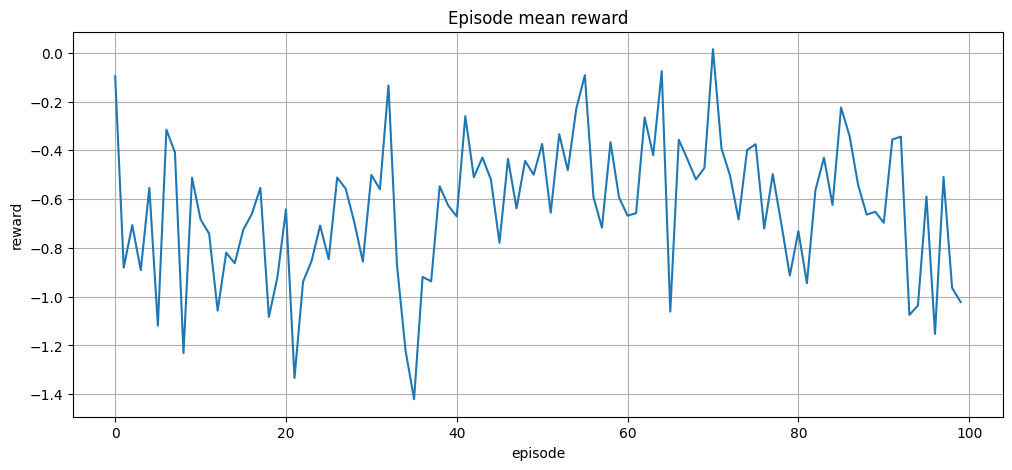

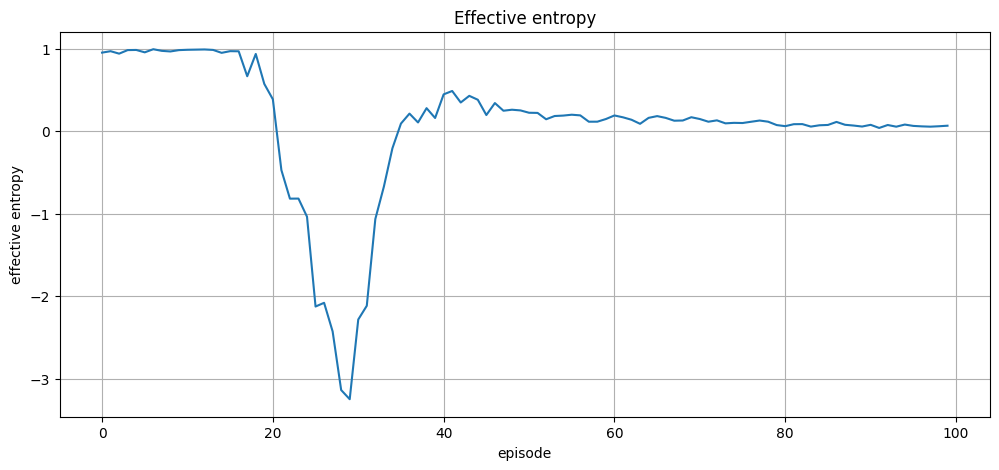

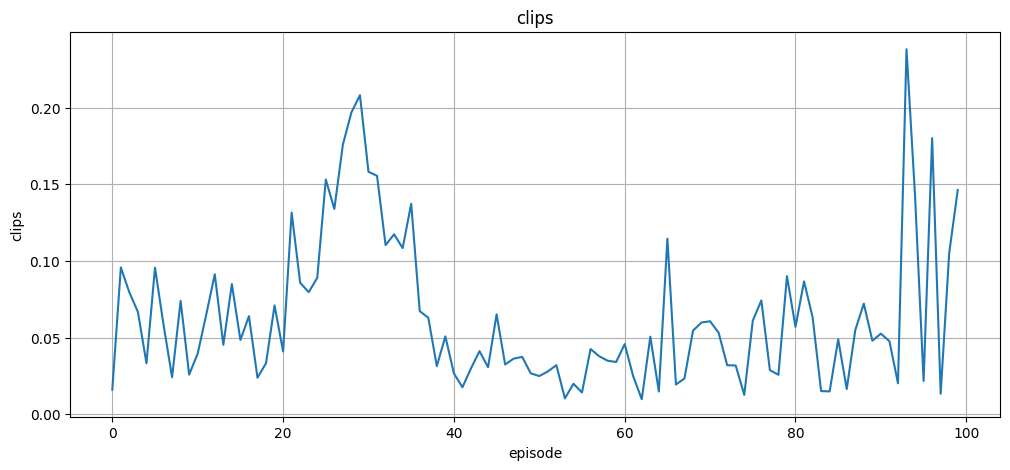

In [9]:
from scripts.utils import plot

plot(
    None,
    logs['mean_reward'],
    'episode',
    'reward',
    'Episode mean reward'
)

plot(
    None,
    logs['entropy_alt'],
    'episode',
    'effective entropy',
    'Effective entropy'
)

plot(
    None,
    logs['clips'],
    'episode',
    'clips',
    'clips'
)

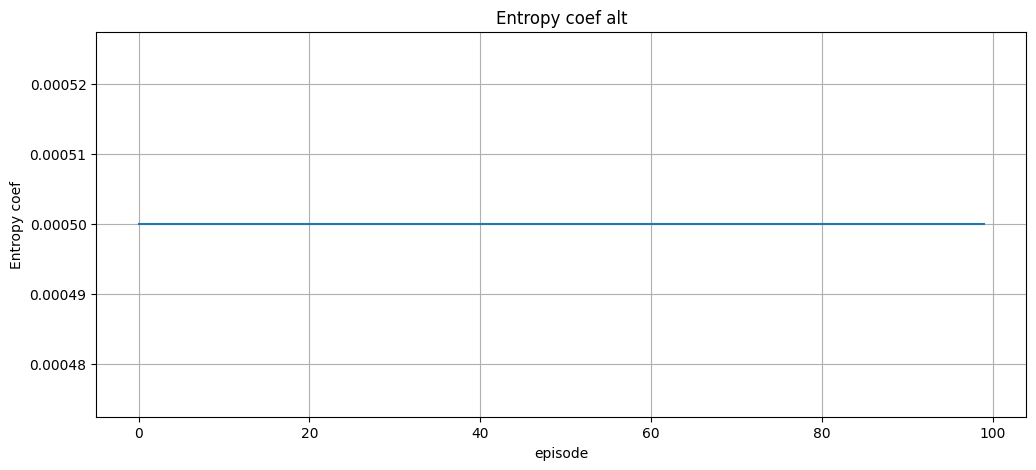

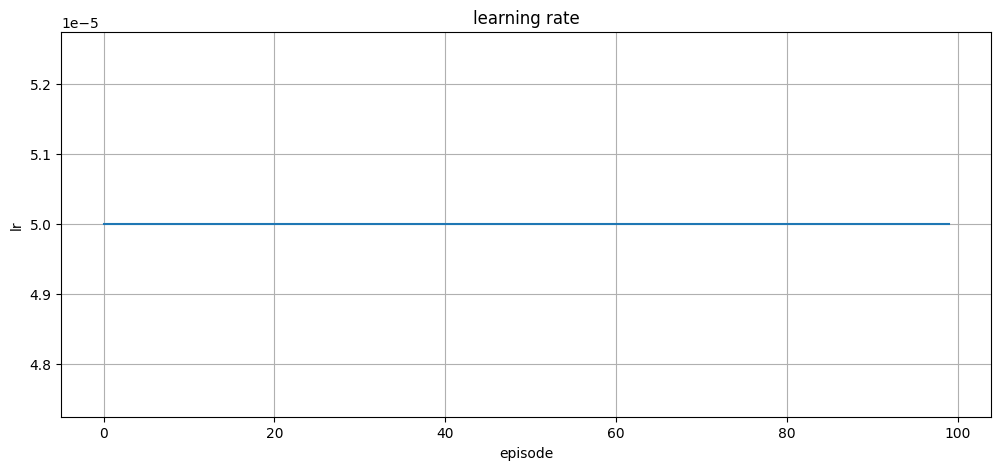

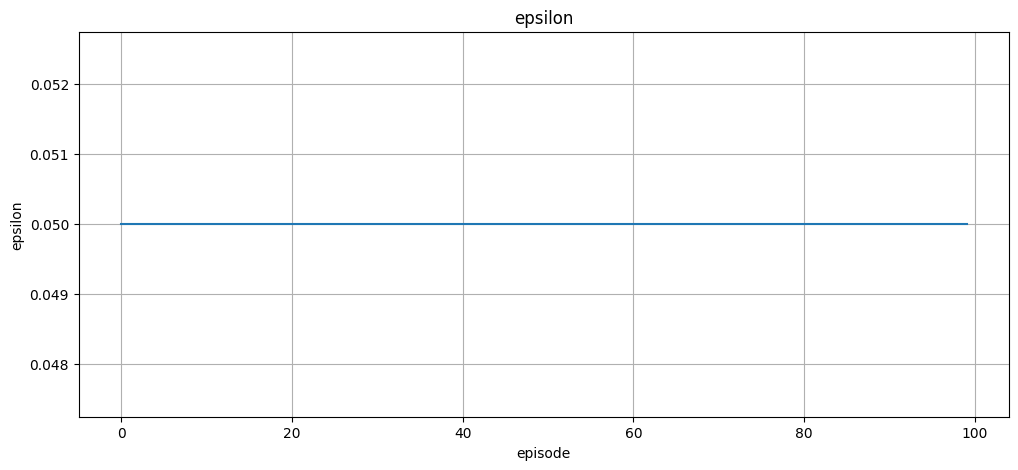

In [10]:
plot(
    None,
    logs['ent_coef_alt'],
    'episode',
    'Entropy coef',
    'Entropy coef alt'
)

plot(
    None,
    logs['learning_rate'],
    'episode',
    'lr',
    'learning rate'
)

plot(
    None,
    logs['epsilon'],
    'episode',
    'epsilon',
    'epsilon'
)

In [14]:
from scripts.variable_leverage_env_3 import agentDLVEnvV3

TOP_LEVERAGE = 2.2
BOTTOM_LEVERAGE = 1.8

def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    cr = 1/obs[1]

    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = True,
    index=True,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset(seed=400)
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

a1 = info['loss_rate']
loss1 = info['losses']

obs, _ = eval_env.reset(seed=400)
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

a2 = info['loss_rate']
loss2 = info['losses']

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
Env True rng test: 0.1990988109705989
Env True rng test: 0.1990988109705989


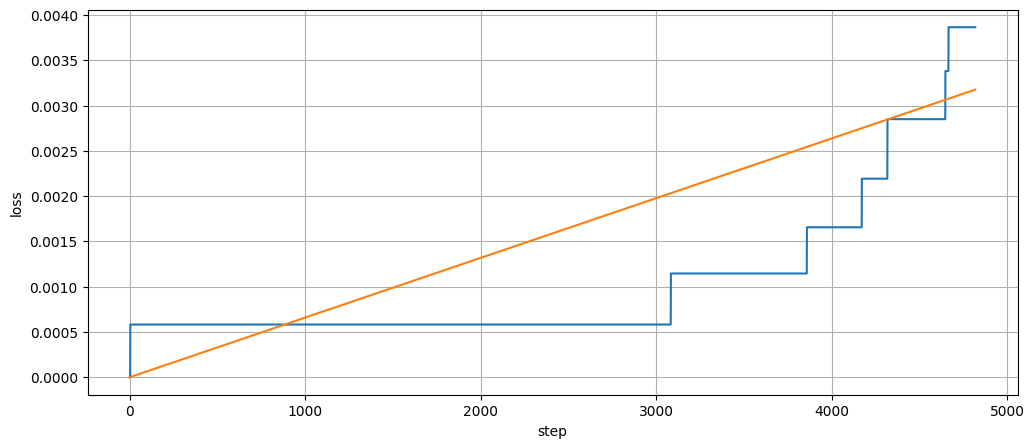

In [15]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(info['losses']))

plt.figure(figsize=(12, 5))
plt.plot(time, loss1)
plt.plot(time, time*a1)
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True)
plt.show()

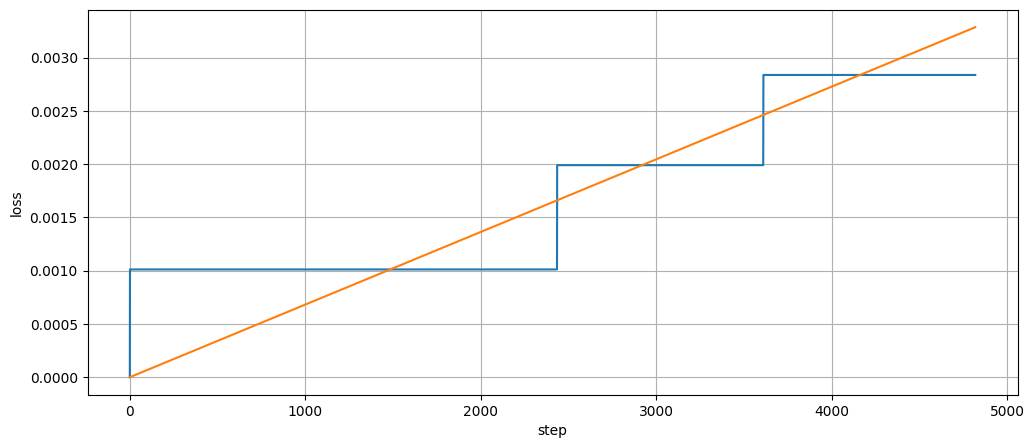

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(info['losses']))

plt.figure(figsize=(12, 5))
plt.plot(time, loss2)
plt.plot(time, time*a2)
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True)
plt.show()

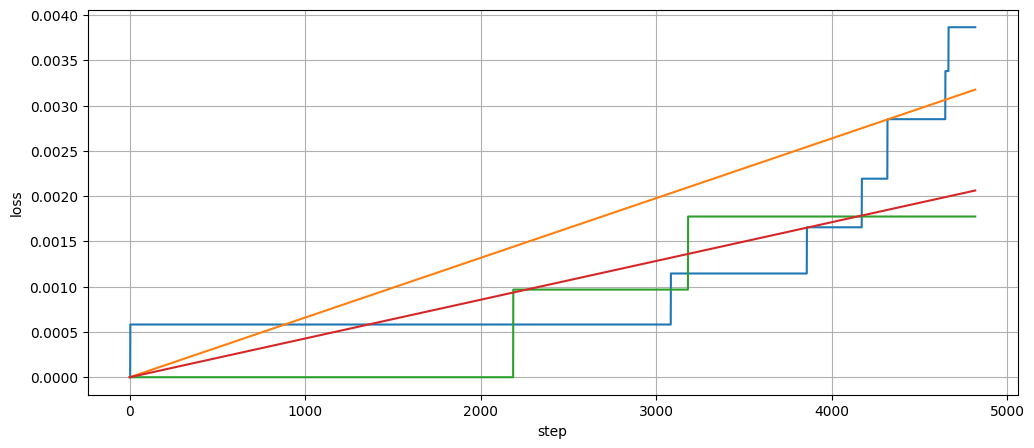

In [16]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(info['losses']))

plt.figure(figsize=(12, 5))
plt.plot(time, loss1)
plt.plot(time, time*a1)
plt.plot(time, loss2)
plt.plot(time, time*a2)
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True)
plt.show()